<a href="https://colab.research.google.com/github/TiTKi1/-ML/blob/main/%D0%9B%D0%912_%D0%9C%D0%B0%D0%BC%D0%B5%D0%B4%D0%BE%D0%B2_3_9_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2.

---

Мамедов, 3-9

---

**Був присутній на парі**


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 31.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudshogaa/titanic-dataset/versions/1


In [2]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
df.duplicated().sum()

np.int64(128)

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

df.drop(['Cabin'], axis=1, inplace=True) # вирішили видалити колонку[cite: 2]
df.drop(['Embarked'], axis=1, inplace=True)

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
# Clean the dataset of unnecessary columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [10]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_1483/909601743.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8. Вивести описову статистику датасету describe()


In [12]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.

In [17]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11.Вивести 5 останніх рядків датасету.

In [15]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [18]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [19]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


Була різниця, виживали переважно жінки

13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [21]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


1 клас найвищий рівень, звідти був вихід до шлюбок та він був розташований зверху

14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [23]:
# Середній вік пасажирів, які вижили та не вижили
age_survival = df.groupby('Survived')['Age'].mean()

print(f"Середній вік тих, хто не вижив (0): {age_survival[0]:.2f} років")
print(f"Середній вік тих, хто вижив (1): {age_survival[1]:.2f} років")

Середній вік тих, хто не вижив (0): 30.03 років
Середній вік тих, хто вижив (1): 28.29 років


Вік впливає на виживання, більша кількість виживших це діти та люди похилого віку

15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [26]:
# Separate dataset in 6 buckets by Fare sorted in ascending order
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

# Find share of survivors in each bucket
for i in range(6):
    surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
    print(f'Share of survivors in bucket {i}: {surv_rate * 100:.2f}%')

Share of survivors in bucket 0: 20.51%
Share of survivors in bucket 1: 19.08%
Share of survivors in bucket 2: 36.69%
Share of survivors in bucket 3: 43.62%
Share of survivors in bucket 4: 41.78%
Share of survivors in bucket 5: 69.80%


/tmp/ipykernel_1483/402236946.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


Під час розбиття тарифу на 6 категорій , відсоток виживаності послідовно зростає від найдешевшої (категорія 0) до найдорожчої (категорія 5). Тариф впливав тому, що 1 клас був на верхніх палубах, тому виживаємість там була більшою, а 2 та 3 класи знаходились нижче, тому їм було важче

16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [25]:
# Find median fare for the class
for i in range(1, 4):
    median_fare = df[df['Pclass'] == i]['Fare'].median()
    print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


Так, різниця є, між 2 та 3 вона незначна. А от якщо порівнювати 1 клас з 2 та 3 то різниция у 4-6 разів

17. Як пов'язаний середній вік з виживанням пассажирів

<Axes: xlabel='Age', ylabel='Count'>

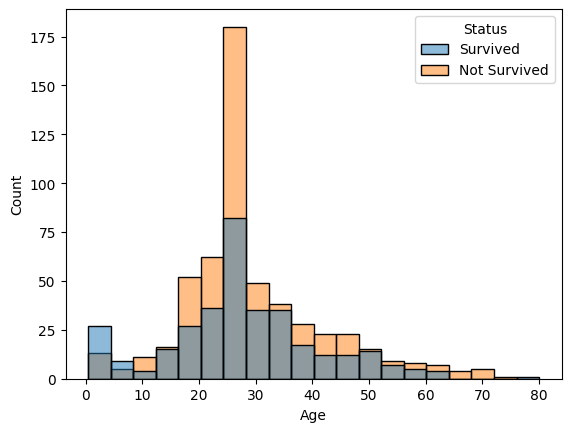

In [27]:
# Combine the data into a single DataFrame
df_survived = df[df['Survived'] == 1][['Age']]
df_survived['Status'] = 'Survived'

df_not_survived = df[df['Survived'] == 0][['Age']]
df_not_survived['Status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

# Plot the histogram with hue
sns.histplot(data=df_combined, x='Age', hue='Status', bins=20)

Зв'язок є нелінійним: найкращі шанси мали наймолодші пасажири (діти), тоді як середній вік дорослих практично не впливав на шанси вижити.

In [28]:
# Clalculate survival rate per class per sex
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male  " if j == 0 else "female"} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male   passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male   passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male   passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


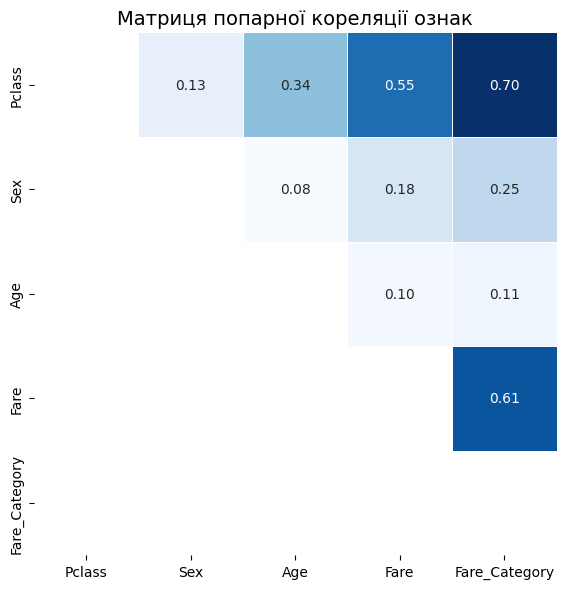

In [29]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='Blues', # змінено колірну палітру (можна також 'coolwarm', 'viridis', 'YlGnBu')
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)), # маскуємо нижній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
from google.colab import files

uploaded = files.upload()



Saving bestsellers (1).csv to bestsellers (1).csv


**Завдання 2**

1. Прочитайте csv файл (використовуйте функцію read_csv)




In [33]:
df = pd.read_csv('bestsellers (1).csv', encoding='latin1')
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


2. Реалізувати 2 способи завантаження файлу (з комп'ютера та кагл)

In [42]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
print("Path to dataset files:", path)

file_path = os.path.join(path, "bestsellers with categories.csv")
df = pd.read_csv(file_path)
df

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


3. Виведіть перших п'ять рядків (використовується функція head)

In [44]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


4. Виведіть розміри датасету (використовуйте метод shape)

In [46]:
df.shape

(550, 7)

5. Наявність дублікатів за назвою, видалити дублікати

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.duplicated(subset='Name').sum()

np.int64(0)

In [50]:
df = df.drop_duplicates(subset='Name')

In [51]:
df.shape

(351, 7)

6. Про скільки книг зберігає дані датасет?

Про 550 книг зберігає дані, але 351 з них унікальна

7. Перейменувати стовпці
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [53]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


8. Виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)

In [54]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


9. Перевірте, які унікальні значення в колонці genre (використовуйте функцію unique)
Які є унікальні жанри?

In [71]:
df['genre'].value_counts()

df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

Жанри Non Fiction та Fiction є унікальними

10. Подивіться розподіл цін: побудуйте діаграму (використовуйте kind='hist')

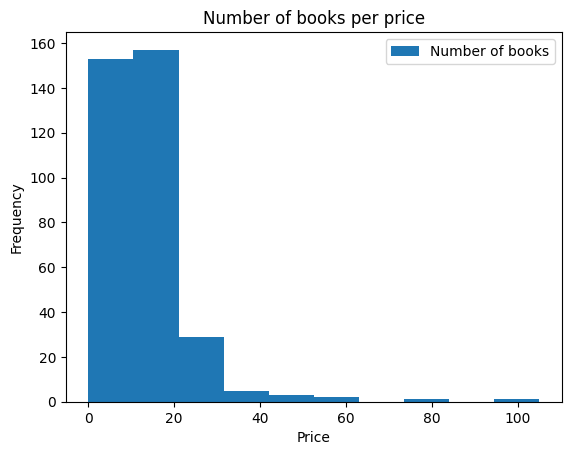

In [59]:
df['price'].plot(kind='hist', label='Number of books')
plt.xlabel('Price')
plt.title('Number of books per price')
plt.legend()
plt.show()

11. Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)

In [60]:
print(f"Максимальна ціна: {df['price'].max()}")
print(f"Мінімальна ціна: {df['price'].min()}")
print(f"Середня ціна: {df['price'].mean():.1f}")
print(f"Медіанна ціна: {df['price'].median()}")

Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.1
Медіанна ціна: 12.0


12. Який рейтинг у датасеті найвищий?

In [61]:
df['user_rating'].max()

4.9

13. Скільки книг мають такий рейтинг?

In [62]:
df[df['user_rating'] == 4.9]['name'].count()

np.int64(28)

14. У якої книги найбільше відгуків?

In [63]:
df[df['reviews'] == df['reviews'].max()]

,name,author,user_rating,reviews,price,year,genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


15. З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)?

In [64]:
max_price = df[df['year'] == 2015]['price'].max()
df[(df['year'] == 2015) & (df['price'] == max_price)]

,name,author,user_rating,reviews,price,year,genre
132,Go Set a Watchman: A Novel,Harper Lee,3.6,14982,19,2015,Fiction


16. Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?

In [65]:
df[(df['year'] == 2010) & (df['genre'] == 'Fiction')].count()['name']

np.int64(17)

17. Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)?

In [68]:
df[(df['user_rating'] == 4.9) & (df['year'].isin([2010, 2011]))]

,name,author,user_rating,reviews,price,year,genre
187,Jesus Calling: Enjoying Peace in His Presence ...,Sarah Young,4.9,19576,8,2011,Non Fiction


18. Відсортуємо за зростанням ціни всі книги, які потрапили в рейтинг у 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).
Яка книга остання у відсортованому списку?

In [69]:
df[(df['price'] < 8) & (df['year'] == 2015)].sort_values('price')

,name,author,user_rating,reviews,price,year,genre
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
28,Baby Touch and Feel: Animals,DK,4.6,5360,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction
16,Adult Coloring Book: Stress Relieving Animal D...,Blue Star Coloring,4.6,2925,6,2015,Non Fiction
17,Adult Coloring Book: Stress Relieving Patterns,Blue Star Coloring,4.4,2951,6,2015,Non Fiction
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


19. Вивести максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте maxта min). Не беріть усі стовпці, виберете тільки потрібні вам

In [70]:
df.groupby('genre')['price'].agg(['min', 'max'])

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105
